## 7.2 梯度优化方法 - AdaGrad

#### 1. 为什么需要 AdaGrad
Momentum 可以解决：
* 梯度震荡问题

但是仍然存在一个重要问题：
* 所有参数使用同一个学习率

然而在神经网络中，不同参数的梯度规模可能差别很大。

例如：
* 参数A的梯度 ≈ 0.001
* 参数B的梯度 ≈ 10

如果使用相同学习率：
* A 更新很慢
* B 更新过快

这会导致：
* 训练效率下降
* 甚至训练不稳定

因此我们希望：

`不同参数使用不同的学习率`

这就是 AdaGrad 的核心思想。

Momentum 改进的是：
* 梯度大小
* 梯度方向

AdaGrad 改进的是：
* 学习率

```
方法	主要优化对象	核心思想
Momentum	梯度方向	利用历史梯度平滑更新方向
AdaGrad	学习率	为每个参数自适应调整学习率

```

#### 2. AdaGrad 的核心思想
AdaGrad（Adaptive Gradient）提出：

为每个参数自适应调整学习率

基本思想：
* 梯度大的参数 → 学习率变小
* 梯度小的参数 → 学习率变大

这样可以：
* 平衡不同参数的更新速度

#### 3. AdaGrad 的数学公式
AdaGrad 会记录 历史梯度平方的累计值。

![St = St-1 + 9ł.png](<attachment:St = St-1 + 9ł.png>)

其中：

![Pasted Graphic 21.png](<attachment:Pasted Graphic 21.png>)

参数更新公式：

![0 = 0-..png](<attachment:0 = 0-..png>)

其中：

![Pasted Graphic 23.png](<attachment:Pasted Graphic 23.png>)
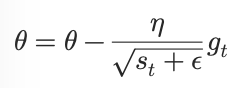
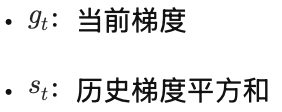
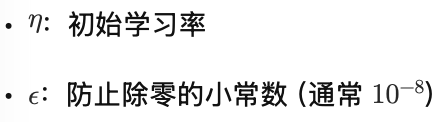
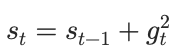

##### ⚠️注意：
```
这里的每一次的梯度表示同一层的各个参数的梯度在每一个次 batch 训练之后的梯度
而不是表示同一个 batch 中的每一层的各个参数的梯度
```
1. 每一个 batch 会计算一次梯度
2. 这个梯度包含 所有参数的梯度
3. Momentum 会 对每一个参数的梯度序列做 EMA

这里的：

`g_t`

其实是：

`当前 batch 的梯度`

所以：
```
g1 = 第1个batch得到的梯度
g2 = 第2个batch得到的梯度
g3 = 第3个batch得到的梯度
```

#### 4. AdaGrad 的直观理解
从公式可以看到：

![Pasted Graphic 24.png](<attachment:Pasted Graphic 24.png>)

其实就是：
* 新的学习率
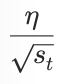

##### 4.1 如果梯度很大
假设：
```
g1 = 10
g2 = 8
g3 = 9
```

则：

`s_t = 100 + 64 + 81`

变得很大：
* √s_t ↑

因此：
* 学习率 ↓
* 更新变小。

##### 4.2 如果梯度很小
假设：
```
g1 = 0.001
g2 = 0.002
g3 = 0.001
```

则：
* s_t 很小

因此：
* 学习率相对较大
* 更新速度更快。


#### 5. AdaGrad 的直观理解
AdaGrad 可以理解为：
* 每个参数都有自己的学习率

学习率会根据：
* 历史梯度大小自动调整

换句话说：
* 经常更新的参数 → 学习率逐渐减小
* 很少更新的参数 → 学习率保持较大

这在一些场景非常有效，例如：
* 稀疏特征（Sparse Features）

例如：
* NLP
* 推荐系统

#### 6. AdaGrad 的优点
AdaGrad 的优点包括：

##### 6.1 自动调整学习率

##### 6.2 对稀疏数据效果好
在 NLP 等任务中：
* 很多特征很少出现
* 表现为稀疏特征矩阵

AdaGrad 可以：
* 为这些特征保持较大学习率

##### 6.3 简单易实现
只需要维护一个变量：

`s_t`

#### 7. AdaGrad 的缺点
AdaGrad 最大的问题是：
* 学习率会不断减小

因为：

![St = St-1 + g}.png](<attachment:St = St-1 + g}.png>)

是 不断累加的。

因此：
* √s_t 会越来越大

导致：
* 学习率越来越小

最终可能出现：
* 参数几乎不再更新
* 训练停止
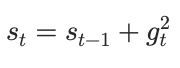

#### 8. AdaGrad 的改进
由于 AdaGrad 学习率衰减过快，后来提出了改进算法：
```
算法	改进点
RMSProp	使用 EMA 替代累加
Adam	结合 Momentum + RMSProp
```
也就是说：

`AdaGrad → RMSProp → Adam`

是一个逐步改进的过程。

#### 9. AdaGrad 在 Pytorch 中的实现
在 Pytorch 中，AdaGrad 使用：

`torch.optim.Adagrad`

##### 9.1 基本写法

In [ ]:
import torch

model = torch.nn.Linear(1, 1)

optimizer = torch.optim.Adagrad(
    model.parameters(),
    lr=0.01,
)

##### 9.2 常见参数

In [ ]:
optimizer_2 = torch.optim.Adagrad(
    model.parameters(),
    lr=0.01,
    lr_decay=0,
    weight_decay=0,
    eps=1e-10
)

##### 9.3 参数说明
* lr
    * 初始学习率
* lr_decay
    * 学习率衰减系数
* weight_decay
    * L2 正则化系数
* eps
    * 防止分母为 0 的小常数

##### 9.4 说明：
Pytorch 会在内部自动完成，不需要手动写公式

并按照 AdaGrad 的规则更新参数。